# Convolutional Neural Networks

# Importar Librerías

In [62]:
import numpy as np
import os
import re
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [63]:
import keras
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from keras.models import Sequential,Model
from tensorflow.keras.layers import Input
from keras.layers import Dense, Dropout, Flatten
#from keras.layers import Conv2D, MaxPooling2D
#from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    BatchNormalization, SeparableConv2D, MaxPooling2D, Activation, Flatten, Dropout, Dense, Conv2D
)
from keras.layers import LeakyReLU

# Cargar set de Imágenes

In [64]:
dirname = os.path.join(os.getcwd(),'animals')
imgpath = dirname + os.sep 

images = []
directories = []
dircount = []
prevRoot=''
cant=0

print("leyendo imagenes de ",imgpath)

for root, dirnames, filenames in os.walk(imgpath):
    for filename in filenames:
        if re.search("\.(jpg|jpeg|png|bmp|tiff)$", filename):
            cant=cant+1
            filepath = os.path.join(root, filename)
            image = plt.imread(filepath)
            if(len(image.shape)==3):
                
                images.append(image)
            b = "Leyendo..." + str(cant)
            print (b, end="\r")
            if prevRoot !=root:
                print(root, cant)
                prevRoot=root
                directories.append(root)
                dircount.append(cant)
                cant=0
dircount.append(cant)

dircount = dircount[1:]
dircount[0]=dircount[0]+1
print('Directorios leidos:',len(directories))
print("Imagenes en cada directorio", dircount)
print('suma Total de imagenes en subdirs:',sum(dircount))

<>:14: SyntaxWarning: invalid escape sequence '\.'
<>:14: SyntaxWarning: invalid escape sequence '\.'
C:\Users\crist\AppData\Local\Temp\ipykernel_7088\344621359.py:14: SyntaxWarning: invalid escape sequence '\.'
  if re.search("\.(jpg|jpeg|png|bmp|tiff)$", filename):


leyendo imagenes de  c:\Users\crist\Desktop\TEC\Semestre_9\IA\Proyectos-IA\CNN\animals\
c:\Users\crist\Desktop\TEC\Semestre_9\IA\Proyectos-IA\CNN\animals\ant 1
c:\Users\crist\Desktop\TEC\Semestre_9\IA\Proyectos-IA\CNN\animals\bird 1193
c:\Users\crist\Desktop\TEC\Semestre_9\IA\Proyectos-IA\CNN\animals\chimpanzee 1100
c:\Users\crist\Desktop\TEC\Semestre_9\IA\Proyectos-IA\CNN\animals\frog 949
c:\Users\crist\Desktop\TEC\Semestre_9\IA\Proyectos-IA\CNN\animals\spider 916
c:\Users\crist\Desktop\TEC\Semestre_9\IA\Proyectos-IA\CNN\animals\whale 1089
Directorios leidos: 6
Imagenes en cada directorio [1194, 1100, 949, 916, 1089, 747]
suma Total de imagenes en subdirs: 5995


# Creamos las etiquetas

In [65]:
labels=[]
indice=0
for cantidad in dircount:
    for i in range(cantidad):
        labels.append(indice)
    indice=indice+1
print("Cantidad etiquetas creadas: ",len(labels))


Cantidad etiquetas creadas:  5995


In [66]:
animales=[]
indice=0
for directorio in directories:
    name = directorio.split(os.sep)
    print(indice , name[len(name)-1])
    animales.append(name[len(name)-1])
    indice=indice+1

0 ant
1 bird
2 chimpanzee
3 frog
4 spider
5 whale


In [67]:
y = np.array(labels)
X = np.array(images, dtype=np.uint8) #convierto de lista a numpy



# Find the unique numbers from the train labels
classes = np.unique(y)
nClasses = len(classes)
print('Total number of outputs : ', nClasses)
print('Output classes : ', classes)

Total number of outputs :  6
Output classes :  [0 1 2 3 4 5]


# Creamos Sets de Entrenamiento y Test

In [68]:
train_X,test_X,train_Y,test_Y = train_test_split(X,y,test_size=0.2)
print('Training data shape : ', train_X.shape, train_Y.shape)
print('Testing data shape : ', test_X.shape, test_Y.shape)

Training data shape :  (4796, 32, 32, 3) (4796,)
Testing data shape :  (1199, 32, 32, 3) (1199,)


Text(0.5, 1.0, 'Ground Truth : 1')

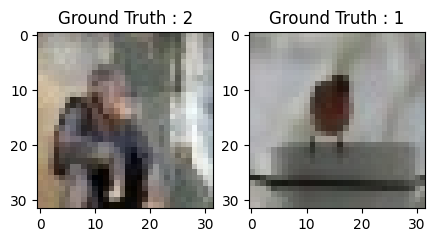

In [69]:
plt.figure(figsize=[5,5])

# Display the first image in training data
plt.subplot(121)
plt.imshow(train_X[0,:,:], cmap='gray')
plt.title("Ground Truth : {}".format(train_Y[0]))

# Display the first image in testing data
plt.subplot(122)
plt.imshow(test_X[0,:,:], cmap='gray')
plt.title("Ground Truth : {}".format(test_Y[0]))

# Preprocesamos las imagenes

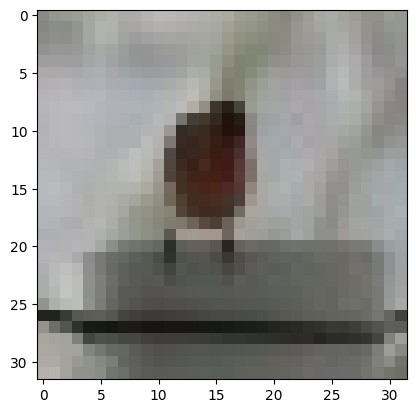

In [70]:
train_X = train_X.astype('float32')
test_X = test_X.astype('float32')
train_X = train_X/255.
test_X = test_X/255.
plt.imshow(test_X[0,:,:])

## Hacemos el One-hot Encoding para la red

In [71]:
# Change the labels from categorical to one-hot encoding
train_Y_one_hot = to_categorical(train_Y)
test_Y_one_hot = to_categorical(test_Y)

# Display the change for category label using one-hot encoding
print('Original label:', train_Y[0])
print('After conversion to one-hot:', train_Y_one_hot[0])

Original label: 2
After conversion to one-hot: [0. 0. 1. 0. 0. 0.]


# Creamos el Set de Entrenamiento y Validación

In [72]:
#Mezclar todo y crear los grupos de entrenamiento y testing
train_X,valid_X,train_label,valid_label = train_test_split(train_X, train_Y_one_hot, test_size=0.2, random_state=13)

In [73]:
print(train_X.shape,valid_X.shape,train_label.shape,valid_label.shape)

(3836, 32, 32, 3) (960, 32, 32, 3) (3836, 6) (960, 6)


# Creamos el modelo de CNN

In [74]:
#declaramos variables con los parámetros de configuración de la red
INIT_LR = 1e-3 # Valor inicial de learning rate. El valor 1e-3 corresponde con 0.001
epochs = 20 # Cantidad de iteraciones completas al conjunto de imagenes de entrenamiento
batch_size = 64 # cantidad de imágenes que se toman a la vez en memoria

In [75]:
animals_model = Sequential()
animals_model.add(Conv2D(32, kernel_size=(3, 3),activation='linear',padding='same',input_shape=(32,32,3)))
animals_model.add(LeakyReLU(alpha=0.1))
animals_model.add(MaxPooling2D((2, 2),padding='same'))
animals_model.add(Dropout(0.5))


animals_model.add(Flatten())
animals_model.add(Dense(32, activation='linear'))
animals_model.add(LeakyReLU(alpha=0.1))
animals_model.add(Dropout(0.5))
animals_model.add(Dense(nClasses, activation='softmax'))

c:\Users\crist\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\crist\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [76]:
animals_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │       262,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 263,270 (1.00 MB)

 Trainable params: 263,270 (1.00 MB)

 Non-trainable params: 0 (0.00 B)

In [77]:
animals_model.compile(loss=keras.losses.categorical_crossentropy, optimizer=tf.keras.optimizers.SGD(learning_rate=INIT_LR),metrics=['accuracy'])

# Entrenamos el modelo: Aprende a clasificar imágenes

In [78]:
# este paso puede tomar varios minutos, dependiendo de tu ordenador, cpu y memoria ram libre
animals_train = animals_model.fit(train_X, train_label, batch_size=batch_size,epochs=epochs,verbose=1,validation_data=(valid_X, valid_label))

Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.1700 - loss: 1.8171 - val_accuracy: 0.2021 - val_loss: 1.7729
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.1791 - loss: 1.7968 - val_accuracy: 0.1979 - val_loss: 1.7688
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.1997 - loss: 1.7852 - val_accuracy: 0.2000 - val_loss: 1.7665
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.1812 - loss: 1.7833 - val_accuracy: 0.2062 - val_loss: 1.7634
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.2015 - loss: 1.7755 - val_accuracy: 0.2042 - val_loss: 1.7596
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.2002 - loss: 1.7718 - val_accuracy: 0.2052 - val_loss: 1.7563
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.1934 - loss: 1.7669 - val_accuracy: 0.2094 - val_loss: 1.7511
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.2041 - loss: 1.7632 - val_accuracy: 0.2083 - v

In [79]:
# guardamos la red, para reutilizarla en el futuro, sin tener que volver a entrenar
animals_model.save("animals.h5")

# Evaluamos la red

In [80]:
test_eval = animals_model.evaluate(test_X, test_Y_one_hot, verbose=1)

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2911 - loss: 1.6444


In [81]:
print('Test loss:', test_eval[0])
print('Test accuracy:', test_eval[1])

Test loss: 1.6443673372268677
Test accuracy: 0.2910758852958679


In [82]:
animals_train.history

{'accuracy': [0.16996872425079346,
  0.17909280955791473,
  0.1996871680021286,
  0.18117831647396088,
  0.20151199400424957,
  0.20020854473114014,
  0.19343066215515137,
  0.20411887764930725,
  0.21167883276939392,
  0.2046402543783188,
  0.21324296295642853,
  0.21793535351753235,
  0.22523461282253265,
  0.22106361389160156,
  0.2338373363018036,
  0.23748695850372314,
  0.25026068091392517,
  0.25677788257598877,
  0.264598548412323,
  0.262773722410202],
 'loss': [1.8171464204788208,
  1.7967621088027954,
  1.7852108478546143,
  1.7833442687988281,
  1.775504469871521,
  1.771796464920044,
  1.7668670415878296,
  1.7631951570510864,
  1.7594268321990967,
  1.7576779127120972,
  1.7453862428665161,
  1.7399400472640991,
  1.7319191694259644,
  1.727378010749817,
  1.7245354652404785,
  1.714895486831665,
  1.7065211534500122,
  1.6979485750198364,
  1.6891368627548218,
  1.6828101873397827],
 'val_accuracy': [0.20208333432674408,
  0.1979166716337204,
  0.20000000298023224,
  0.2

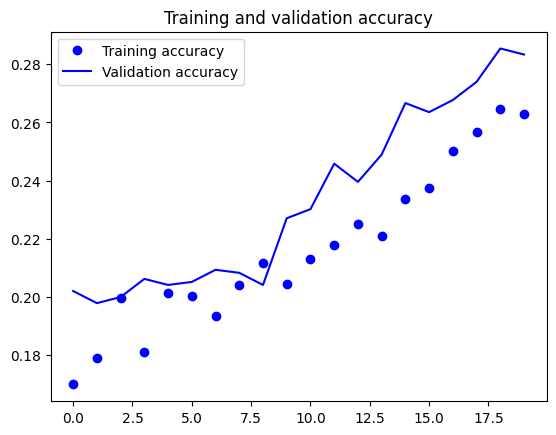

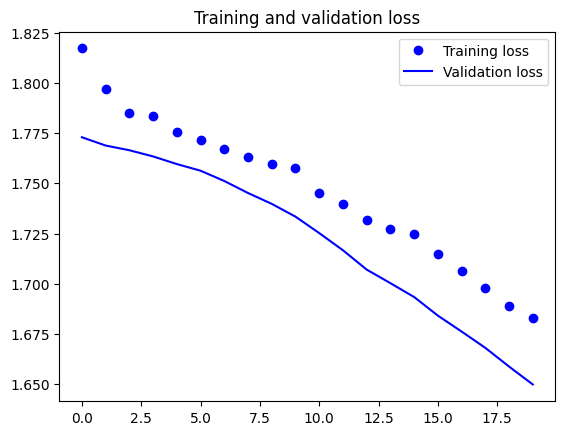

In [83]:
accuracy = animals_train.history['accuracy']
val_accuracy = animals_train.history['val_accuracy']
loss = animals_train.history['loss']
val_loss = animals_train.history['val_loss']
epochs = range(len(accuracy))
plt.plot(epochs, accuracy, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracy, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

In [84]:
predicted_classes2 = animals_model.predict(test_X)

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [85]:
predicted_classes=[]
for predicted_animal in predicted_classes2:
    predicted_classes.append(predicted_animal.tolist().index(max(predicted_animal)))
predicted_classes=np.array(predicted_classes)

In [86]:
predicted_classes.shape, test_Y.shape

((1199,), (1199,))

# Aprendamos de los errores: Qué mejorar

Found 349 correct labels


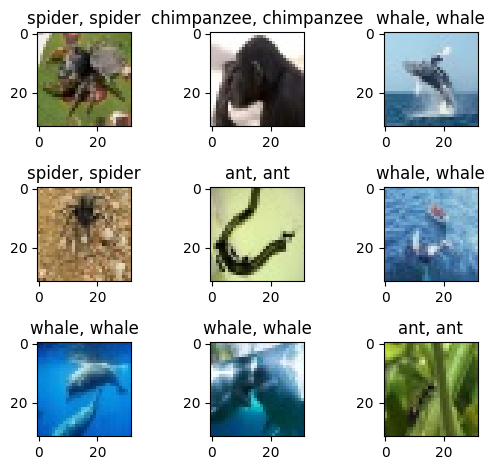

In [87]:
correct = np.where(predicted_classes==test_Y)[0]
print("Found %d correct labels" % len(correct))
for i, correct in enumerate(correct[0:9]):
    plt.subplot(3,3,i+1)
    plt.imshow(test_X[correct].reshape(32,32,3), cmap='gray', interpolation='none')
    plt.title("{}, {}".format(animales[predicted_classes[correct]],
                                                    animales[test_Y[correct]]))

    plt.tight_layout()

Found 850 incorrect labels


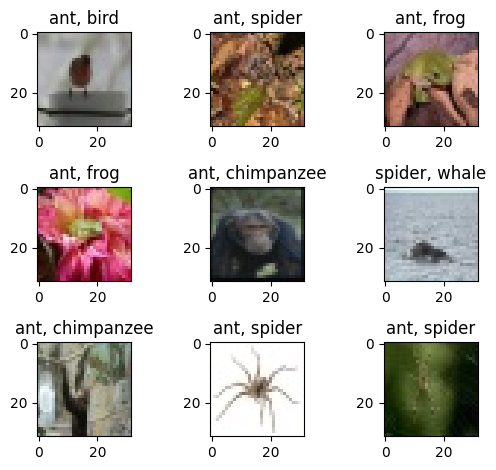

In [88]:
incorrect = np.where(predicted_classes!=test_Y)[0]
print("Found %d incorrect labels" % len(incorrect))
for i, incorrect in enumerate(incorrect[0:9]):
    plt.subplot(3,3,i+1)
    plt.imshow(test_X[incorrect].reshape(32,32,3), cmap='gray', interpolation='none')
    plt.title("{}, {}".format(animales[predicted_classes[incorrect]],
                                                    animales[test_Y[incorrect]]))
    plt.tight_layout()

In [89]:
target_names = ["Class {}".format(i) for i in range(nClasses)]
print(classification_report(test_Y, predicted_classes, target_names=target_names))

              precision    recall  f1-score   support

     Class 0       0.22      0.71      0.33       231
     Class 1       0.09      0.00      0.01       224
     Class 2       0.62      0.07      0.12       194
     Class 3       0.64      0.04      0.07       183
     Class 4       0.23      0.28      0.25       223
     Class 5       0.86      0.70      0.77       144

    accuracy                           0.29      1199
   macro avg       0.44      0.30      0.26      1199
weighted avg       0.40      0.29      0.24      1199



## Matriz de confusion

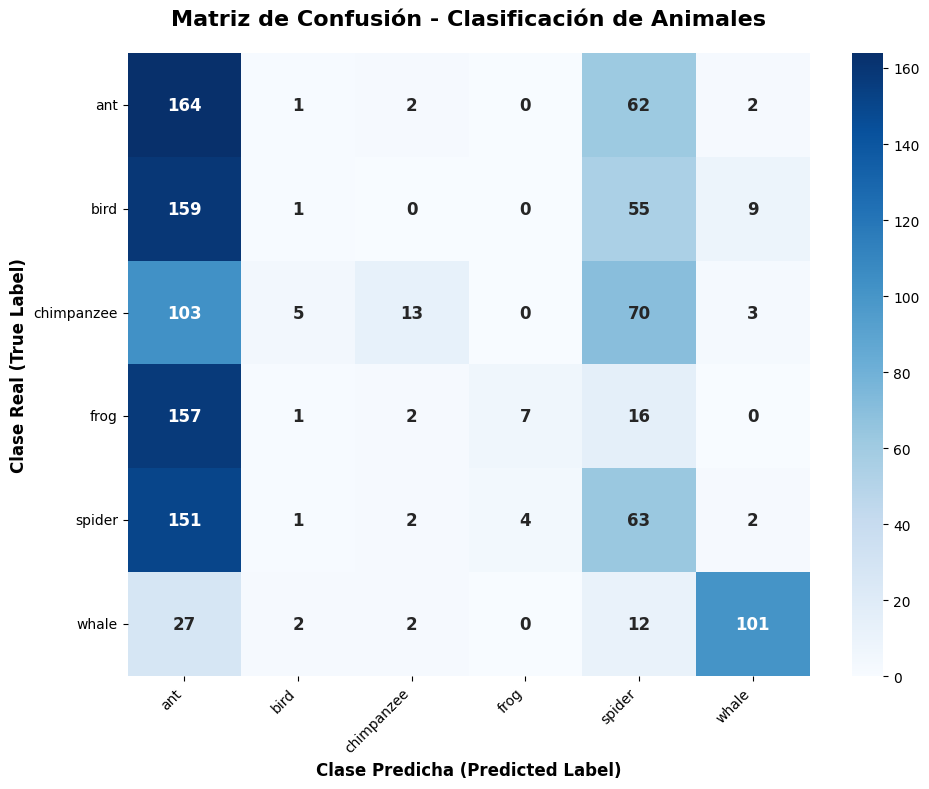

In [90]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# 1. Calcular la matriz de confusión usando las etiquetas reales y predichas
cm = confusion_matrix(test_Y, predicted_classes)

# 2. Graficar la matriz de confusión de manera visual y profesional
try:
    import seaborn as sns
    plt.figure(figsize=(10, 8))
    # Usamos una paleta de colores azul sofisticada y premium
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=animales, yticklabels=animales,
                annot_kws={"size": 12, "weight": "bold"})
    plt.title('Matriz de Confusión - Clasificación de Animales', fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('Clase Real (True Label)', fontsize=12, fontweight='bold')
    plt.xlabel('Clase Predicha (Predicted Label)', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()
    plt.show()
except ImportError:
    # Si seaborn no está instalado, usamos la visualización nativa de scikit-learn
    fig, ax = plt.subplots(figsize=(10, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=animales)
    disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation=45)
    plt.title('Matriz de Confusión - Clasificación de Animales', fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('Clase Real (True Label)', fontsize=12, fontweight='bold')
    plt.xlabel('Clase Predicha (Predicted Label)', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


In [92]:
from skimage.transform import resize

images=[]
# AQUI ESPECIFICAMOS UNAS IMAGENES
filenames = [r'C:\Users\crist\Desktop\TEC\Semestre_9\IA\Proyectos-IA\CNN\test\ejemploAnimal.jpg']

for filepath in filenames:
    image = plt.imread(filepath,0)
    image_resized = resize(image, (32, 32),anti_aliasing=True,clip=False,preserve_range=True)
    images.append(image_resized)

X = np.array(images, dtype=np.uint8) #convierto de lista a numpy
test_X = X.astype('float32')
test_X = test_X / 255.

predicted_classes = animals_model.predict(test_X)

for i, img_tagged in enumerate(predicted_classes):
    print(filenames[i], animales[img_tagged.tolist().index(max(img_tagged))])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
C:\Users\crist\Desktop\TEC\Semestre_9\IA\Proyectos-IA\CNN\test\ejemploAnimal.jpg whale
